# Contact-threshold profile example

This notebook mirrors the toy `rc` recovery workflow: an external contact score is thresholded into a driven-transition contact probability, one model is fit per candidate threshold, and the final ELBO profile identifies the generating threshold.

In [1]:
from __future__ import annotations

import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")

import matplotlib.pyplot as plt
import numpy as np

from viprodyne import CAVIConfig, MS2Dataset, ModelConfig, profile_contact_threshold
from viprodyne.core.ms2_kernels import ProximalKernel

np.set_printoptions(precision=4, suppress=True)

The toy data below uses a two-state promoter. Contact activates the off-to-on transition, and the contact probability is generated by thresholding an observed score.

In [2]:
def expected_loading_probability(contact_probability: np.ndarray, dt: np.float32) -> np.ndarray:
    kon = np.float32(1.0)
    koff = np.float32(0.25)
    loading_rates = np.array([0.02, 1.5], dtype=np.float32)
    state = np.array([1.0, 0.0], dtype=np.float32)
    loading_probability = []
    for contact in np.asarray(contact_probability, dtype=np.float32):
        loading_probability.append(np.sum(state * (1.0 - np.exp(-loading_rates * dt))))
        p_on = contact * (1.0 - np.exp(-kon * dt))
        p_off = 1.0 - np.exp(-koff * dt)
        state = np.array(
            [
                state[0] * (1.0 - p_on) + state[1] * p_off,
                state[1] * (1.0 - p_off) + state[0] * p_on,
            ],
            dtype=np.float32,
        )
        state = state / np.sum(state)
    return np.asarray(loading_probability, dtype=np.float32)


def expected_ms2_signal(
    *,
    sampling_times: np.ndarray,
    loading_times: np.ndarray,
    loading_probability: np.ndarray,
    kernel: ProximalKernel,
) -> np.ndarray:
    weights = np.asarray(
        kernel(
            np.asarray(sampling_times, dtype=np.float32)[:, None]
            - np.asarray(loading_times, dtype=np.float32)[None, :]
        ),
        dtype=np.float32,
    )
    return np.asarray(weights @ loading_probability.astype(np.float32), dtype=np.float32)

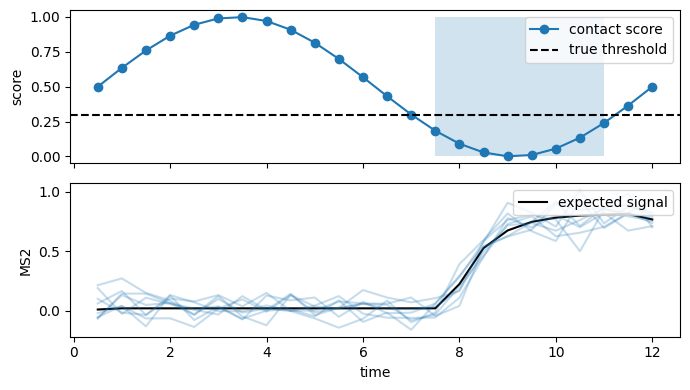

In [3]:
rng = np.random.default_rng(2026)
n_observations = 24
n_traces = 8
dt = np.float32(0.5)
time_grid = np.arange(n_observations + 1, dtype=np.float32) * dt
observation_times = time_grid[1:]
loading_times = time_grid[:-1]
contact_score = (
    0.5 + 0.5 * np.sin(np.linspace(0.0, 2.0 * np.pi, n_observations, dtype=np.float32))
).astype(np.float32)
true_threshold = np.float32(0.3)
contact_probability = (contact_score < true_threshold).astype(np.float32)

loading_probability = expected_loading_probability(contact_probability, dt=dt)
kernel = ProximalKernel(
    t_rise=np.float32(0.5),
    t_plateau=np.float32(0.5),
    rna_intensity=np.float32(1.0),
)
clean_signal = expected_ms2_signal(
    sampling_times=observation_times,
    loading_times=loading_times,
    loading_probability=loading_probability,
    kernel=kernel,
)
observed = clean_signal[None, :] + rng.normal(
    0.0,
    0.08,
    size=(n_traces, n_observations),
).astype(np.float32)

dataset = MS2Dataset(
    name="toy",
    observed=observed,
    noise_std=np.float32(0.1),
    time_grid=time_grid,
)

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
axes[0].plot(observation_times, contact_score, marker="o", label="contact score")
axes[0].axhline(true_threshold, color="black", linestyle="--", label="true threshold")
axes[0].fill_between(observation_times, 0.0, 1.0, where=contact_probability > 0, alpha=0.2)
axes[0].set_ylabel("score")
axes[0].legend(loc="upper right")

axes[1].plot(observation_times, clean_signal, color="black", label="expected signal")
axes[1].plot(observation_times, observed.T, color="tab:blue", alpha=0.25)
axes[1].set_xlabel("time")
axes[1].set_ylabel("MS2")
axes[1].legend(loc="upper right")
fig.tight_layout()

`profile_contact_threshold` builds and fits a fresh model for each candidate, injects the candidate-specific contact probability into the dataset, and returns the final ELBO profile.

In [4]:
config = ModelConfig(
    n_states=2,
    pol2_mode="transfer",
    ms2_kernel="proximal",
    t_rise=np.float32(0.5),
    t_plateau=np.float32(0.5),
    rna_intensity=np.float32(1.0),
    driven_transition_indices=(1,),
    driven_rate_initial=np.float32(0.8),
    driven_rate_bounds=(1e-3, 5.0),
)

profile = profile_contact_threshold(
    datasets=(dataset,),
    config=config,
    contact_scores=contact_score,
    candidate_values=np.linspace(0.2, 0.8, 7, dtype=np.float32),
    fit_config=CAVIConfig(max_iterations=10, min_iterations=10, tolerance=0.0),
)

print("candidate thresholds:", profile.candidate_values)
print("profile ELBOs:", profile.elbos)
print("best threshold:", profile.best_value)
print("true threshold:", true_threshold)

candidate thresholds: [0.2 0.3 0.4 0.5 0.6 0.7 0.8]
profile ELBOs: [-111.6325 -111.2572 -117.0955 -121.7616 -131.1767 -137.9259 -142.5331]
best threshold: 0.3
true threshold: 0.3


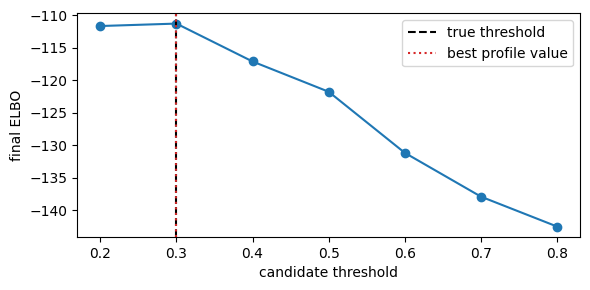

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(profile.candidate_values, profile.elbos, marker="o")
ax.axvline(true_threshold, color="black", linestyle="--", label="true threshold")
ax.axvline(profile.best_value, color="tab:red", linestyle=":", label="best profile value")
ax.set_xlabel("candidate threshold")
ax.set_ylabel("final ELBO")
ax.legend(loc="best")
fig.tight_layout()